# CH4 marginality: exact-year UNL budgets

Nebraska MLRA 106 dryland corn; odd years 2001–2021. Original yields are read-only. **2021 is experimental.** See METHODS.md and the eligibility register. Economics is blocked for every year without a matching original UNL budget. Install requirements.txt if your runtime lacks the recorded dependencies.

In [2]:
from pathlib import Path
import sys, importlib.metadata, json
from google.colab import drive, auth
ROOT=Path('/content/drive/MyDrive/PHD/CSP3_GPP_outputs')
if not ROOT.exists():
 try:
  drive.mount('/content/drive',force_remount=False)
 except Exception:
  auth.authenticate_user()
  drive.mount('/content/drive',force_remount=True)
PACKAGE=ROOT/'CH4_marginality/20260928_corefilter_exact_year_v2/code'
sys.path.insert(0,str(PACKAGE))
import importlib.util
print('Google Colab runtime available:', importlib.util.find_spec('google.colab') is not None)
print({p:importlib.metadata.version(p) for p in ['numpy','pandas','rasterio','geopandas','scipy','nbclient']})

Mounted at /content/drive
Google Colab runtime available: True
{'numpy': '2.1.3', 'pandas': '2.2.3', 'rasterio': '1.5.1', 'geopandas': '1.1.4', 'scipy': '1.16.3', 'nbclient': '0.10.4'}


In [3]:
import unittest
suite=unittest.defaultTestLoader.discover(str(PACKAGE/'ch4_marginality/tests'))
result=unittest.TextTestRunner(verbosity=2).run(suite)
assert result.wasSuccessful()

test_app_threshold_serialization_retains_ties (test_core.ScientificContracts.test_app_threshold_serialization_retains_ties) ... ok
test_breakeven_and_missing (test_core.ScientificContracts.test_breakeven_and_missing) ... ok
test_budget_totals_alignment (test_core.ScientificContracts.test_budget_totals_alignment) ... ok
test_constant_or_missing (test_core.ScientificContracts.test_constant_or_missing) ... ok
test_gate_for_every_source (test_core.ScientificContracts.test_gate_for_every_source) ... ok
test_operator_share (test_core.ScientificContracts.test_operator_share) ... ok
test_quartile_ties (test_core.ScientificContracts.test_quartile_ties) ... ok
test_sensitivity (test_core.ScientificContracts.test_sensitivity) ... ok
test_spatial_aggregation_missing_and_area (test_core.ScientificContracts.test_spatial_aggregation_missing_and_area) ... ok
test_unit_conversion (test_core.ScientificContracts.test_unit_conversion) ... ok

---------------------------------------------------------------

In [4]:
import ee
try:
    ee.Initialize(project='ee-njberkowitz95')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='ee-njberkowitz95')
print('Earth Engine authenticated; prior CH4 asset bands:', ee.Image('projects/ee-njberkowitz95/assets/ch4_verified_yields_20260928').bandNames().size().getInfo())

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine authenticated; prior CH4 asset bands: 22


In [5]:
from ch4_marginality.verify_ee_assets import run as verify_earth_engine
from ch4_marginality.verify_app_classes import run as verify_earth_engine_classes
OUTPUT=ROOT/'CH4_marginality/20260928_corefilter_exact_year_v2'
verify_earth_engine(OUTPUT)
verify_earth_engine_classes(OUTPUT)

Earth Engine native statistics and existing-app ACL verified
2019 M1_fixed UNL native classes match
2019 M2_HI_sensitivity UNL native classes match
2021 M1_fixed UNL native classes match
2021 M2_HI_sensitivity UNL native classes match
2019 M1_fixed FINBIN_county native classes match


In [6]:
from ch4_marginality.pipeline import run
OUTPUT=run(ROOT)
print('Completed output:',OUTPUT)

Auditing pinned yield, patch and NCCPI products
INFO:CH4:Auditing pinned yield, patch and NCCPI products
Year 2001 M1_fixed
INFO:CH4:Year 2001 M1_fixed
Year 2001 M2_HI_sensitivity
INFO:CH4:Year 2001 M2_HI_sensitivity
Year 2003 M1_fixed
INFO:CH4:Year 2003 M1_fixed
Year 2003 M2_HI_sensitivity
INFO:CH4:Year 2003 M2_HI_sensitivity
Year 2005 M1_fixed
INFO:CH4:Year 2005 M1_fixed
Year 2005 M2_HI_sensitivity
INFO:CH4:Year 2005 M2_HI_sensitivity
Year 2007 M1_fixed
INFO:CH4:Year 2007 M1_fixed
Year 2007 M2_HI_sensitivity
INFO:CH4:Year 2007 M2_HI_sensitivity
Year 2009 M1_fixed
INFO:CH4:Year 2009 M1_fixed
Year 2009 M2_HI_sensitivity
INFO:CH4:Year 2009 M2_HI_sensitivity
Year 2011 M1_fixed
INFO:CH4:Year 2011 M1_fixed
Year 2011 M2_HI_sensitivity
INFO:CH4:Year 2011 M2_HI_sensitivity
Year 2013 M1_fixed
INFO:CH4:Year 2013 M1_fixed
Year 2013 M2_HI_sensitivity
INFO:CH4:Year 2013 M2_HI_sensitivity
Year 2015 M1_fixed
INFO:CH4:Year 2015 M1_fixed
Year 2015 M2_HI_sensitivity
INFO:CH4:Year 2015 M2_HI_sensitivity

Completed output: /content/drive/MyDrive/PHD/CSP3_GPP_outputs/CH4_marginality/20260928_corefilter_exact_year_v2


In [7]:
%pip -q install reportlab markdown beautifulsoup4
from ch4_marginality.final_checks import verify, pdf_report
validation=verify(OUTPUT)
pdf_report(OUTPUT)
print(json.dumps(validation,indent=2))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.3 MB/s eta 0:00:00
{
  "verified": true,
  "annual_surfaces": 22,
  "sensitivity_rows": 126,
  "cog_count": 211,
  "areas_and_dollars_reconciled": true,
  "ee_native_checks": [
    {
      "year": 2001,
      "scenario": "M1_fixed",
      "count": 3525196,
      "mean_difference": 0.0
    },
    {
      "year": 2001,
      "scenario": "M2_HI_sensitivity",
      "count": 3525196,
      "mean_difference": 0.0
    },
    {
      "year": 2003,
      "scenario": "M1_fixed",
      "count": 3134047,
      "mean_difference": 0.0
    },
    {
      "year": 2003,
      "scenario": "M2_HI_sensitivity",
      "count": 3134047,
      "mean_difference": 0.0
    },
    {
      "year": 2005,
      "scenario": "M1_fixed",
      "count": 3413786,
      "mean_difference": 0.0
    },
    {
      "year": 2005,
      "scenario": "M2_HI_sensitivity",
      "count": 3413786,
      "mean_difference": 0.0
    },
    {
      "year": 2007,
      "scenario"

In [8]:
import pandas as pd
from IPython.display import display,Image
display(pd.read_csv(OUTPUT/'tables/year_eligibility.csv'))
display(pd.read_csv(OUTPUT/'tables/annual_yield.csv'))
s=pd.read_csv(OUTPUT/'tables/sensitivity.csv')
display(s[(s.price_factor==1)&(s.cost_factor==1)])

,year,eligible,status,original_recovered,source_url,file,sha256,budget_number,pdf_page,printed_page,title,assumed_yield_bu_ac
0,2001,False,matching_original_not_recovered,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2003,False,matching_original_not_recovered,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,False,matching_original_not_recovered,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2007,False,matching_original_not_recovered,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009,False,original_recovered_selected_system_absent,True,https://cap.unl.edu/sites/unl.edu.ianr.agecon....,unl_2009.pdf,1c8b75dbfd4a0d4279a8cc5c063c8bad553b4b0ea3753c...,NaN,NaN,NaN,NaN,NaN
5,2011,False,original_recovered_selected_system_absent,True,https://cap.unl.edu/sites/unl.edu.ianr.agecon....,unl_2011.pdf,b8a2152dcc047ac3b2274d4353517f6ffb1f543bc5c930...,NaN,NaN,NaN,NaN,NaN
6,2013,False,original_recovered_selected_system_absent,True,https://digitalcommons.unl.edu/cgi/viewcontent...,unl_2013.pdf,ffed1c52df62b67f7248ac74401b9ea85fd39ad4ec2730...,NaN,NaN,NaN,NaN,NaN
7,2015,False,original_recovered_selected_system_absent,True,https://cap.unl.edu/sites/unl.edu.ianr.agecon....,unl_2015.pdf,f1b374b5075e3e9ed08b42576466fef8fbd5afccebf45f...,NaN,NaN,NaN,NaN,NaN
8,2017,False,original_recovered_selected_system_absent,True,https://cap.unl.edu/sites/unl.edu.ianr.agecon....,unl_2017.pdf,8543fc37829cd7e5dd1d2f903578dad96ffc6831c17d2f...,NaN,NaN,NaN,NaN,NaN
9,2019,True,verified_matching_original,True,https://cap.unl.edu/sites/unl.edu.ianr.agecon....,unl_2019.pdf,6a0693e0c7f8c0f6bcee620595b45fa1214e342147fbd0...,18.0,36.0,30.0,"2019 Budget 18 Corn, Eastern Nebraska, Convent...",160.0


,year,scenario,experimental,n,mean,sd,min,max,p05,p25,...,p75,p95,cutoff_Mg_ha,crop_ha,aoi_boundary_crop_ha,valid_ha,missing_ha,quartile_ha,quartile_percent,nccpi_valid_ha
0,2001,M1_fixed,False,3525196,7.742699,1.400924,1.462590,11.932128,3.745944,7.611388,...,8.445443,9.167906,7.611388,326203.74,3.87,317267.64,8936.10,79316.91,25.000000,317071.98
1,2001,M2_HI_sensitivity,False,3525196,7.742699,1.400924,1.462590,11.932128,3.745944,7.611388,...,8.445443,9.167906,7.611388,326203.74,3.87,317267.64,8936.10,79316.91,25.000000,317071.98
2,2003,M1_fixed,False,3134047,7.300804,1.327090,1.122223,11.649285,3.677274,7.036578,...,8.027013,8.834748,7.036578,289853.73,3.15,282064.23,7789.50,70516.26,25.000072,281917.08
3,2003,M2_HI_sensitivity,False,3134047,7.300804,1.327090,1.122223,11.649285,3.677274,7.036578,...,8.027013,8.834748,7.036578,289853.73,3.15,282064.23,7789.50,70516.26,25.000072,281917.08
4,2005,M1_fixed,False,3413786,7.670830,1.466130,1.082392,13.059136,3.679248,7.546362,...,8.401561,9.217741,7.546362,316100.70,8.91,307240.74,8859.96,76810.23,25.000015,307034.64
5,2005,M2_HI_sensitivity,False,3413786,6.644603,1.269987,0.937586,11.312046,3.187027,6.536786,...,7.277575,7.984563,6.536786,316100.70,8.91,307240.74,8859.96,76810.23,25.000015,307034.64
6,2007,M1_fixed,False,3470152,8.395028,1.618622,1.619521,13.848674,4.040390,8.251139,...,9.181978,10.201137,8.251139,321235.47,7.02,312313.68,8921.79,78078.60,25.000058,312066.72
7,2007,M2_HI_sensitivity,False,3470152,7.826646,1.509034,1.509872,12.911055,3.766837,7.692499,...,8.560315,9.510473,7.692499,321235.47,7.02,312313.68,8921.79,78078.60,25.000058,312066.72
8,2009,M1_fixed,False,2857291,9.163540,1.755894,0.491647,14.513936,4.352019,8.979089,...,10.061958,10.931979,8.979089,265079.88,2.61,257156.19,7923.69,64289.16,25.000044,256965.93
9,2009,M2_HI_sensitivity,False,2857291,9.163540,1.755894,0.491647,14.513936,4.352019,8.979089,...,10.061958,10.931979,8.979089,265079.88,2.61,257156.19,7923.69,64289.16,25.000044,256965.93


,year,scenario,experimental,source,full_economic_account,price_factor,cost_factor,valid_ha,loss_ha,quartile_ha,...,breakeven_bu_ac,breakeven_Mg_ha,return_p05,return_median,return_p95,mean_revenue_usd_ac_2021dollars,mean_cash_margin_usd_ac_2021dollars,return_p05_2021dollars,return_median_2021dollars,return_p95_2021dollars
4,2019,M1_fixed,False,UNL,True,1.0,1.0,352962.18,144884.16,88240.59,...,160.659091,10.084196,-76.250832,7.067880,84.328116,598.668979,213.735711,-80.818002,7.491223,89.379088
13,2019,M1_fixed,False,ERS_Heartland,True,1.0,1.0,352962.18,351499.41,88240.59,...,205.906250,12.924254,-235.520832,-152.202120,-74.941884,598.668979,NaN,-249.627743,-161.318518,-79.430652
22,2019,M1_fixed,False,FINBIN_county,False,1.0,1.0,146321.73,104890.14,43003.08,...,167.999288,10.544923,-284.796634,-19.745451,52.222581,551.977456,53.147693,-301.855001,-20.928138,55.350539
31,2019,M1_fixed,False,FINBIN_state,False,1.0,1.0,352962.18,350994.51,88240.59,...,203.479529,12.771935,-206.891154,-130.946147,-60.523442,545.686775,-37.468367,-219.283242,-138.789384,-64.148594
40,2019,M2_HI_sensitivity,False,UNL,True,1.0,1.0,352962.18,235025.01,88240.59,...,160.659091,10.084196,-94.019068,-13.726147,60.728324,576.927809,191.994541,-99.650496,-14.548298,64.365747
49,2019,M2_HI_sensitivity,False,ERS_Heartland,True,1.0,1.0,352962.18,352382.58,88240.59,...,205.906250,12.924254,-253.289068,-172.996147,-98.541676,576.927809,NaN,-268.460237,-183.358038,-104.443993
58,2019,M2_HI_sensitivity,False,FINBIN_county,False,1.0,1.0,146321.73,125321.04,43003.08,...,167.999288,10.544923,-294.482201,-39.056562,30.297894,531.931928,33.102165,-312.120700,-41.395919,32.112637
67,2019,M2_HI_sensitivity,False,FINBIN_state,False,1.0,1.0,352962.18,352180.98,88240.59,...,203.479529,12.771935,-223.086901,-149.899903,-82.034653,525.869698,-57.285444,-236.449061,-158.878407,-86.948254
76,2021,M1_fixed,True,UNL,True,1.0,1.0,175770.99,2.16,43942.77,...,96.003356,6.025906,410.164448,521.139029,652.260644,1096.029186,750.339186,410.164448,521.139029,652.260644
85,2021,M1_fixed,True,ERS_Heartland,True,1.0,1.0,175770.99,30.60,43942.77,...,131.474832,8.252368,198.754448,309.729029,440.850644,1096.029186,NaN,198.754448,309.729029,440.850644


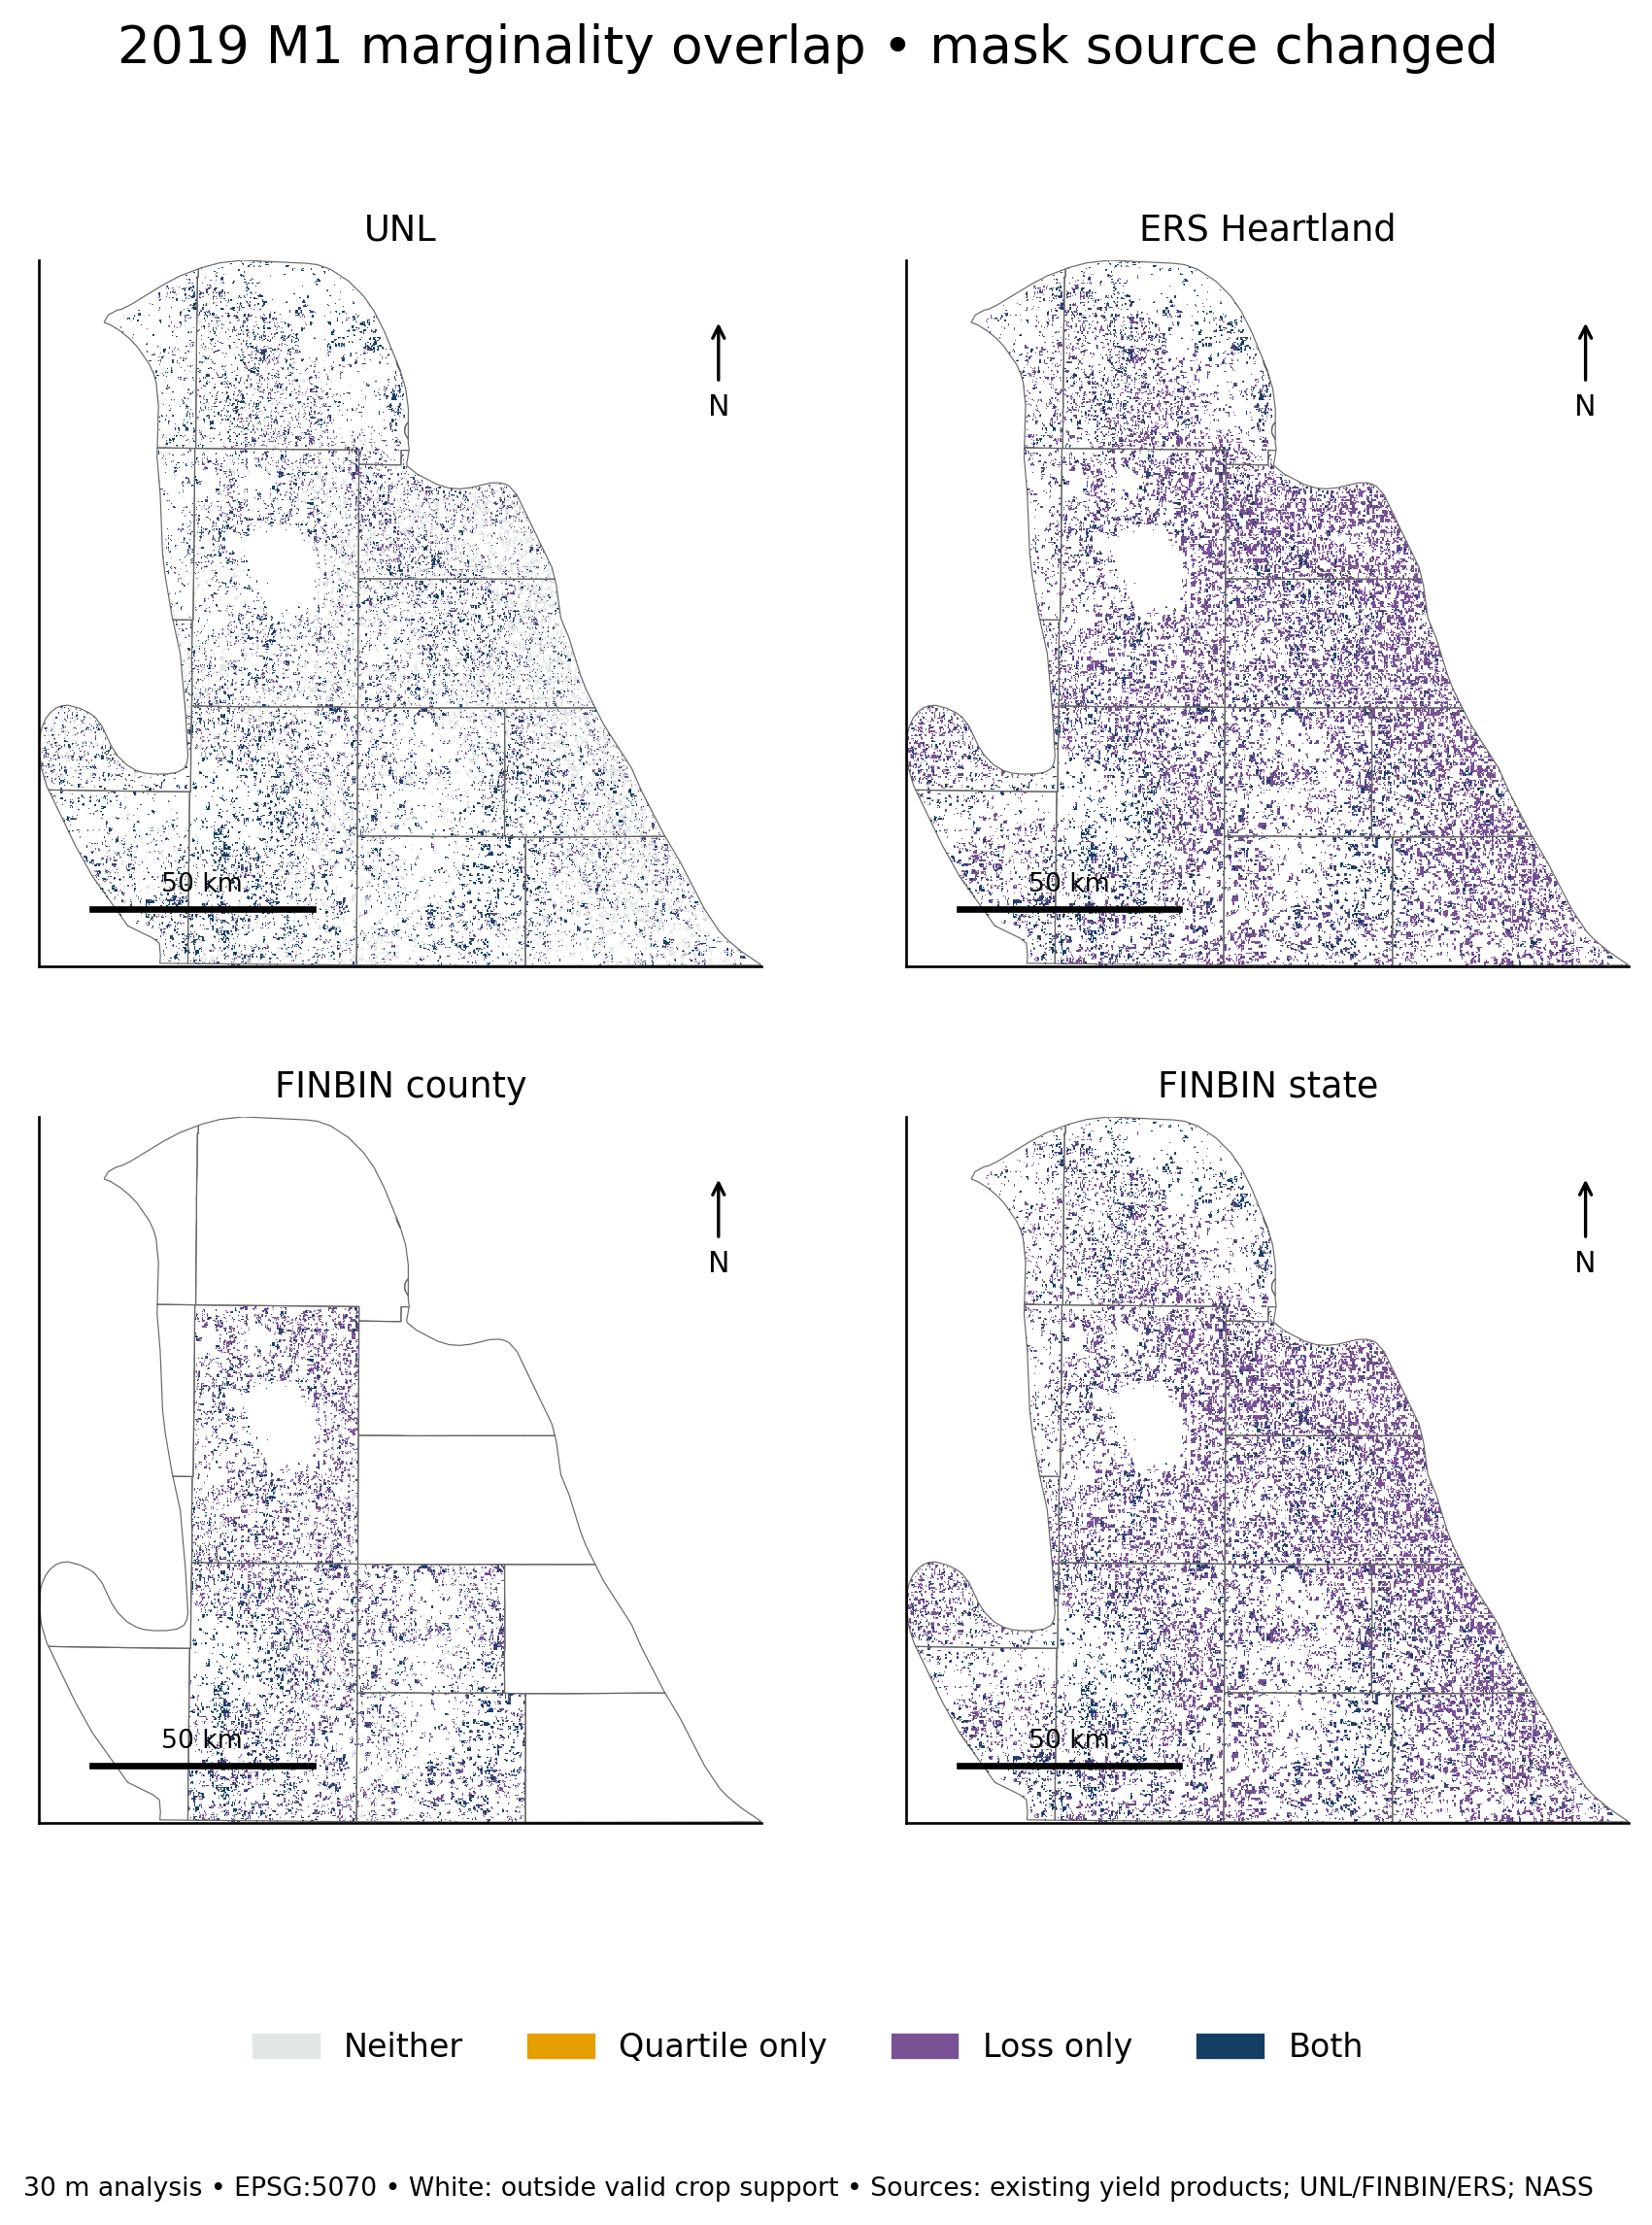

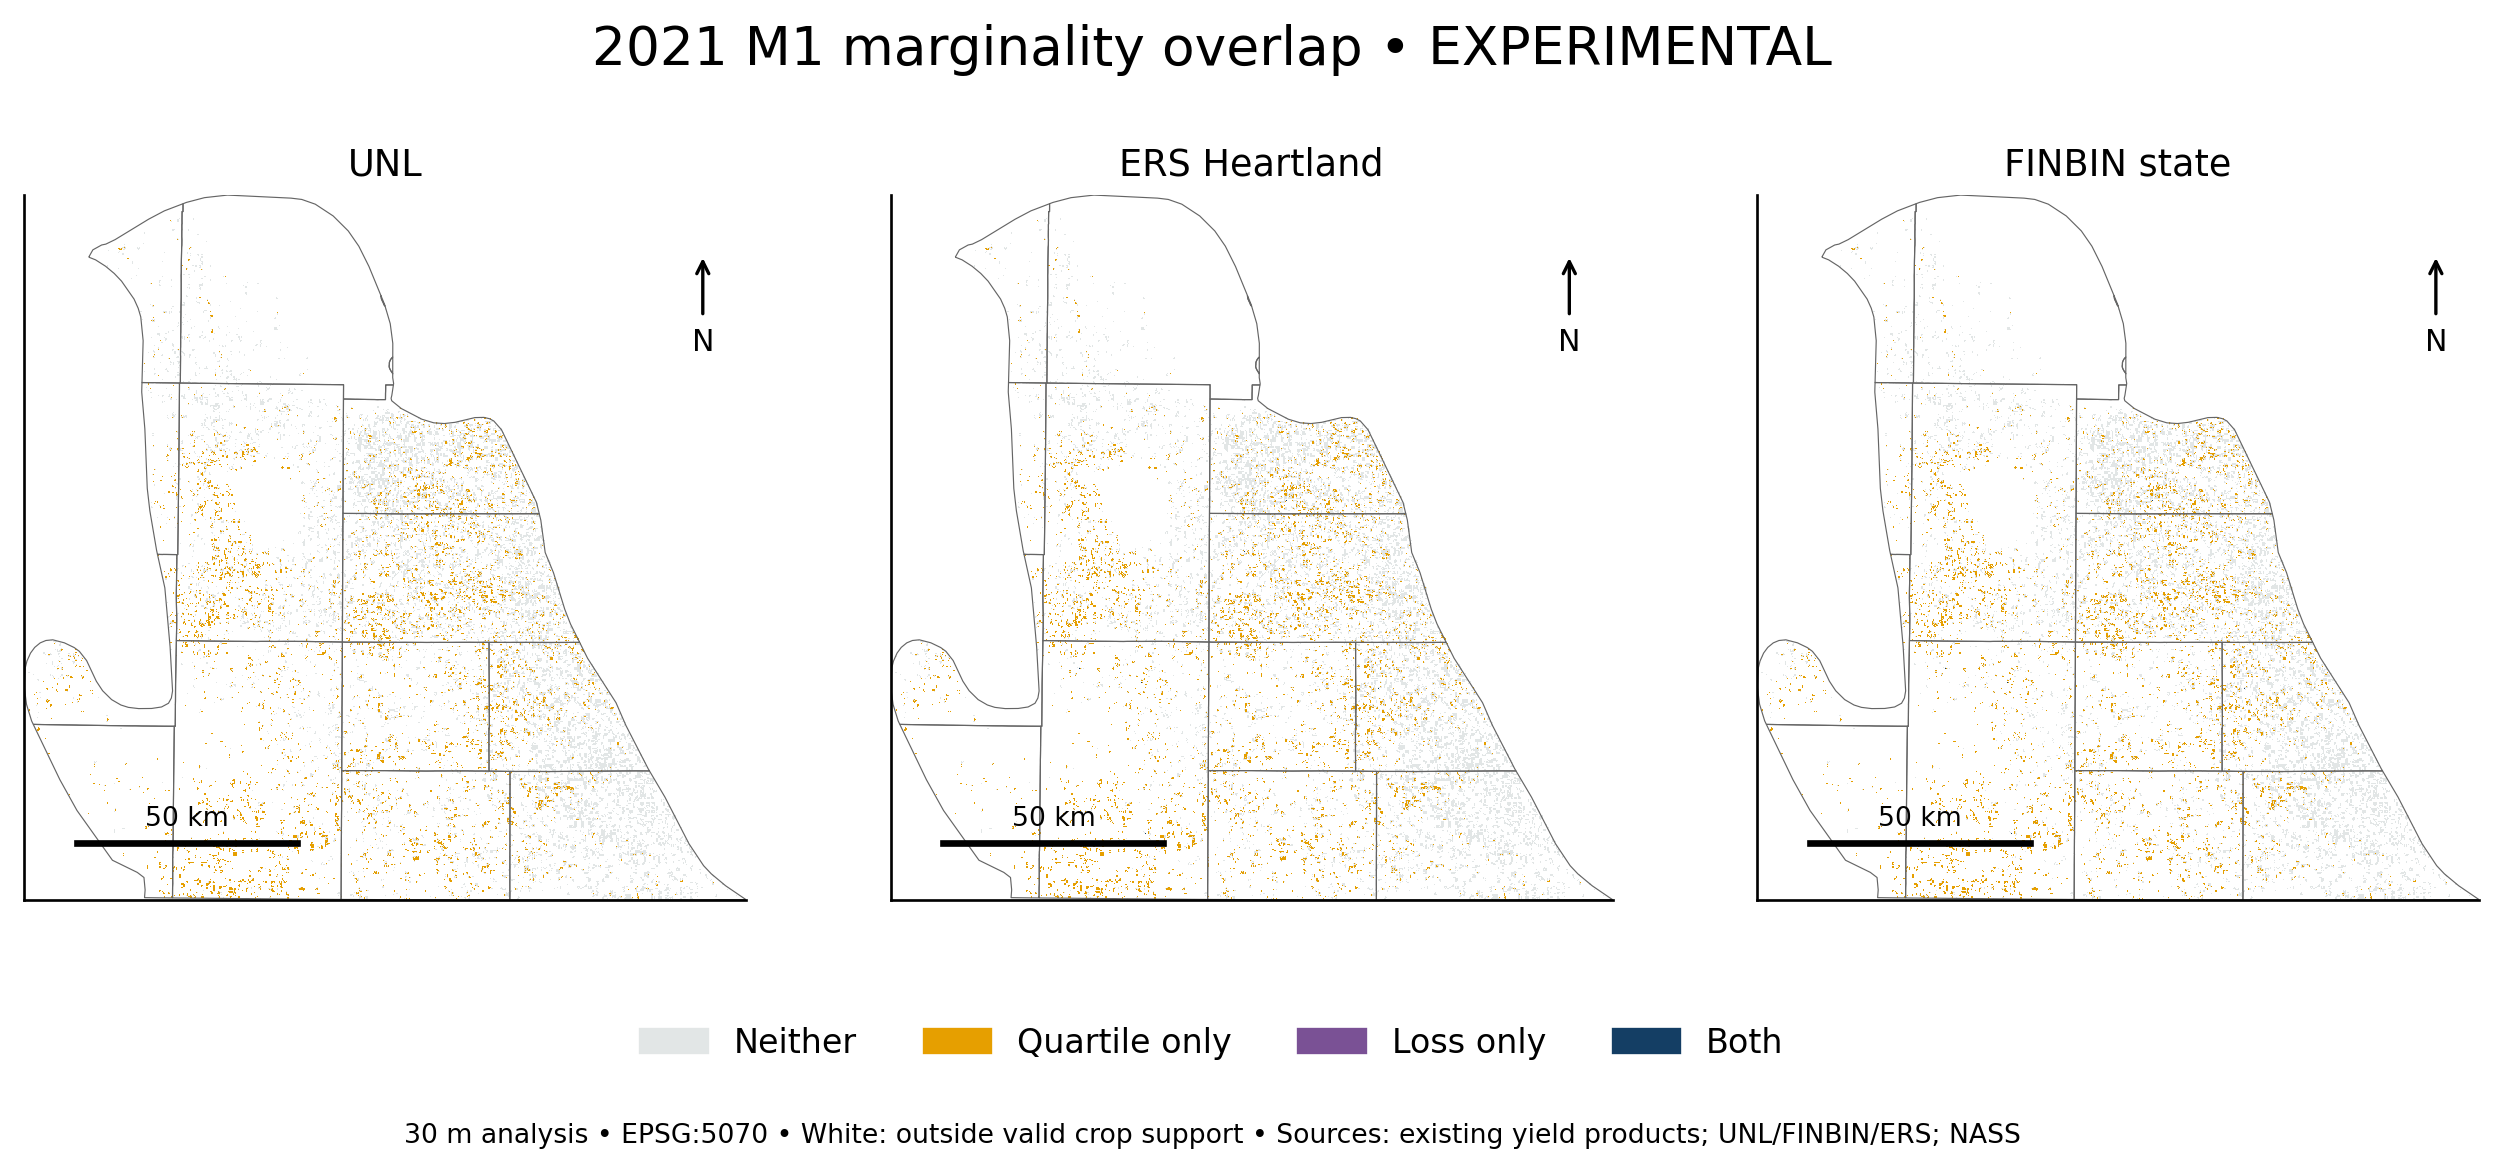

Experimental 2021 excluded from primary temporal summaries.


In [9]:
display(Image(filename=str(OUTPUT/'figures/overlap_maps_2019.png')))
display(Image(filename=str(OUTPUT/'figures/overlap_maps_2021.png')))
print('Experimental 2021 excluded from primary temporal summaries.')

Outputs include the workbook, source ledger, CSV tables, GeoPackage, COGs, publication figures and methods/results report. FINBIN is an operator-account proxy and does not establish complete economic profitability. Missing data never become zero.